# Método PLS

In [1]:
import os
import numpy as np
root_dir = r"../Spectra/FinalSamples"
dir_wln = os.path.join(root_dir, f"Level2/LVL2_Wavelengths.txt")
dir_spec = os.path.join(root_dir, f"Level2/LVL2_All_Spectra.txt")
with open(dir_spec, "r") as f:
    first_line = f.readline().strip()
column_names = first_line.split("\t")
all_Spectra = np.genfromtxt(dir_spec, skip_header=1)   
# data is shape (N, Files)
# to recover column M1_P1:
#spec_m1_p1 = all_Spectra[:, j]
wavelengths = np.loadtxt(dir_wln, delimiter="\t")
dir_concentraciones = os.path.join(root_dir, f"concentraciones.txt")
concentraciones = np.genfromtxt(dir_concentraciones, skip_header=1) 

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

In [3]:
# Construimos X (samples × features) y y (samples × targets)
X = all_Spectra.T     # shape = (n_samples, n_wavelengths)
y = concentraciones                   # shape = (n_samples, 2)

In [4]:
# ————————————— Separar en train y test —————————————
X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.7, random_state=0
)

In [5]:
# ————————————— Ajustar PLS multivariable —————————————
n_components = 20  # elige ≤ min(n_wavelengths, n_samples − 1)
pls = PLSRegression(n_components=n_components)
pls.fit(X_train, y_train)

# Predicción sobre train y test
y_pred_train = pls.predict(X_train)  # shape = (n_train, 2)
y_pred_test  = pls.predict(X_test)   # shape = (n_test, 2)

In [6]:
# ————————————— Cálculo de métricas —————————————
metrics = {}
elements = ['Na', 'Mg']
for j, elem in enumerate(elements):
    # R² y RMSE en entrenamiento
    r2_tr   = r2_score(y_train[:,j], y_pred_train[:,j])
    rmse_tr = np.sqrt(mean_squared_error(y_train[:,j], y_pred_train[:,j]))
    # R² y RMSE en prueba
    r2_te   = r2_score(y_test[:,j], y_pred_test[:,j])
    rmse_te = np.sqrt(mean_squared_error(y_test[:,j], y_pred_test[:,j]))
    metrics[elem] = {
        'R2_train': r2_tr, 'RMSE_train': rmse_tr,
        'R2_test':  r2_te, 'RMSE_test':  rmse_te
    }

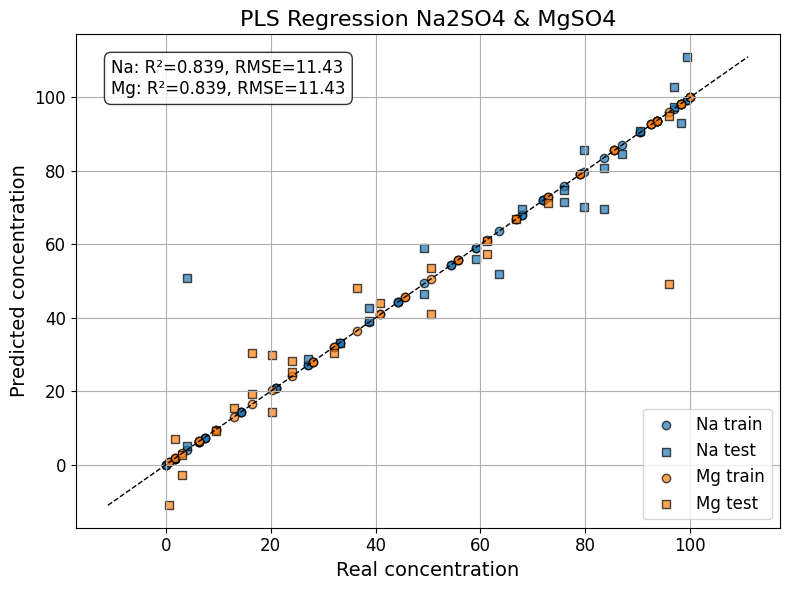

In [8]:
# ————————————— Gráfica única para Na y Mg —————————————
fig, ax = plt.subplots(figsize=(8,6))

# Colores y marcadores
colors = {'Na': 'C0', 'Mg': 'C1'}
markers = {'train': 'o', 'test': 's'}

# Dibujar ambos elementos
for j, elem in enumerate(elements):
    # Train
    ax.scatter(
        y_train[:, j], y_pred_train[:, j],
        c=colors[elem], marker=markers['train'],
        edgecolor='k', alpha=0.7,
        label=f"{elem} train"
    )
    # Test
    ax.scatter(
        y_test[:, j], y_pred_test[:, j],
        c=colors[elem], marker=markers['test'],
        edgecolor='k', alpha=0.7,
        label=f"{elem} test"
    )

# Línea de identidad
mn = min(y.min(), y_pred_train.min(), y_pred_test.min())
mx = max(y.max(), y_pred_train.max(), y_pred_test.max())
ax.plot([mn, mx], [mn, mx], 'k--', lw=1)

# Etiquetas y título
ax.set_xlabel("Real concentration", fontsize=14)
ax.set_ylabel("Predicted concentration", fontsize=14)
ax.set_title("PLS Regression Na2SO4 & MgSO4", fontsize=16)

# Leyenda única
leg = ax.legend(loc='lower right', fontsize=12)
for text in leg.get_texts():
    text.set_fontsize(12)

# Cuadro con métricas de TEST para ambos
text_str = ""
for elem in elements:
    r2 = metrics[elem]['R2_test']
    rmse = metrics[elem]['RMSE_test']
    text_str += f"{elem}: R²={r2:.3f}, RMSE={rmse:.2f}\n"

ax.text(
    0.05, 0.95, text_str.strip(),
    transform=ax.transAxes,
    va='top', ha='left',
    fontsize=12,
    bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.8)
)

ax.tick_params(axis='both', labelsize=12)
ax.grid(True)

plt.tight_layout()
plt.show()
